# Segmentation and data augmentation
This notebook performs segmentation and data augmentation, taking input as a .png file, supposed to be a high-quality scan of the  printed sheet (sheet.pdf) with the black squares filled. 

## Segmentation
By chance, everyone filled the boxes with blue pen, therefore I opted for the following approach for the segmentation: first, the RGB image is converted to grayscale by setting bright and dark pixels to 0, with some tolerance determined by trial and error. This leaves only the (~blue) letters. Then, the original image is again converted to grayscale, this time, by a built-in openCV function. After this, dark pixels are turned to white, and bright pixels to black, according to some threshold value. The boxes are selected by applying a relatively big median filter, which erases all the thin features (such as penstrokes and noise), only keeping the black textboxes. The boxes are selected by a built-in method and the letters in them (from the first image) are cropped to square and resized to 28x28 px. These constitute the data to be augmented.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import convolve2d


In [2]:
import random

In [3]:
# Sorting contours so that we know which letter they correspond to.
# Written by genAI

def sort_contours_by_row(contours, y_tolerance=10):
    """
    Sorts contours top-to-bottom, then left-to-right, grouping them by rows.
    
    :param contours: List of contours from cv2.findContours
    :param y_tolerance: Maximum pixel difference in Y to be considered the same row.
                        (A good rule of thumb is half the average height of your contours)
    """
    if not contours:
        return []

    # 1. Get bounding boxes and pair them with contours
    boxes = [cv2.boundingRect(c) for c in contours]
    
    # 2. Sort strictly top-to-bottom first
    sorted_by_y = sorted(zip(contours, boxes), key=lambda b: b[1][1])
    
    rows = []
    current_row = [sorted_by_y[0]]
    
    # 3. Group into rows based on y_tolerance
    for item in sorted_by_y[1:]:
        contour, box = item
        _, y, _, _ = box
        
        # Get Y coordinate of the first element in the current row
        row_y = current_row[0][1][1]
        
        if abs(y - row_y) <= y_tolerance:
            # It's close enough in Y, add to current row
            current_row.append(item)
        else:
            # Row is finished. Sort the completed row strictly by X (left-to-right)
            current_row.sort(key=lambda b: b[1][0])
            rows.extend(current_row)
            
            # Start a new row
            current_row = [item]
            
    # 4. Sort and add the final row
    if current_row:
        current_row.sort(key=lambda b: b[1][0])
        rows.extend(current_row)
        
    # 5. Extract just the sorted contours without the bounding box data
    final_contours = [item[0] for item in rows]
    
    return final_contours

def segment_images(images):
    letters = np.zeros((26, 3*len(images), 168, 168), dtype=np.float32)
    drawn = 0
    for i in range(len(images)):
        img = cv2.imread(images[i])
        #written by genAI after specifying the requirements (up to the empty comment)
        lower_black = np.array([0, 0, 0])
        upper_black = np.array([70, 70, 70]) 

        # Define "approximately white" (from light gray up to absolute white)
        lower_white = np.array([220, 220, 220]) 
        upper_white = np.array([255, 255, 255])

        # 3. Create masks for these specific color ranges
        # Pixels within the range become 255 (white) in the mask, others become 0 (black)
        mask_black = cv2.inRange(img, lower_black, upper_black)
        mask_white = cv2.inRange(img, lower_white, upper_white)

        # 4. Combine the masks
        # This creates a single mask where ALL black AND white pixels are marked as 255
        combined_mask = cv2.bitwise_or(mask_black, mask_white)

        # 5. Create the final output image
        # Initialize a completely black, single-channel (grayscale) image of the same size
        gray = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

        # We want the "rest" (the pixels NOT in our combined mask) to be white.
        # So, wherever the combined mask is 0 (meaning it wasn't black or white originally),
        # we set the result image to 255 (white).
        gray[combined_mask == 0] = 255
        ###

        #removes "dot" noise from the image
        gray = cv2.medianBlur(gray, 3)

        gray2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, gray2 = cv2.threshold(gray2, 160, 255, cv2.THRESH_BINARY_INV)
        gray2 = cv2.medianBlur(gray2, 11)

        contours, hierarchy = cv2.findContours(gray2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = sort_contours_by_row(contours, 50)
        
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            if(w*h > 1000):  
                letter = gray[y+19:y+187, x+19:x+187]/255.0
                letters[drawn%26, drawn//26,:,:] = letter
                drawn += 1
    return letters

In [4]:


letters = segment_images(['C:/Users/milan/Downloads/imlproject/scan1.png', 'C:/Users/milan/Downloads/imlproject/scan2.png'])

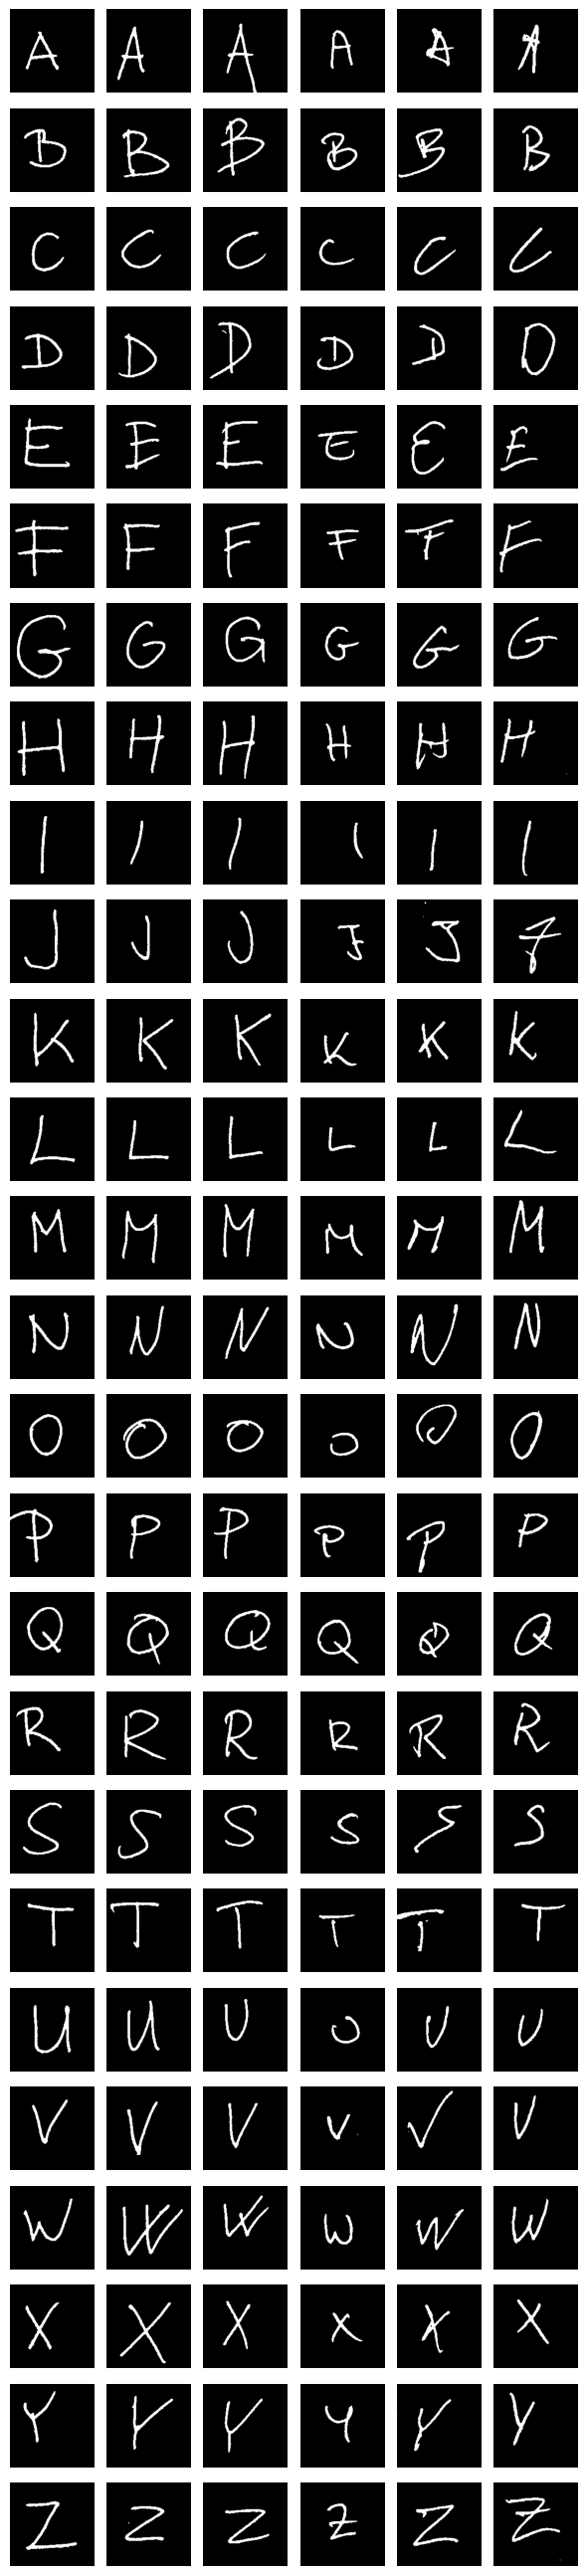

In [5]:
plt.figure(figsize=(6, 26))

for i in range(26):
    
    for j in range(6):
        plt.subplot(26, 6, i*6+j+1)
        plt.imshow(letters[i, j], cmap='gray')
        plt.axis('off')
plt.tight_layout()
plt.show()

## Data Augmentation
At this point, we have 168x168, binary (each pixel is either 1 or 0) images of the letters of the six alphabets. Six images of each letter are not enough to train the classifier, so data augmentation must be performed to make the training data more numerous.
The following procedures will be performed consecutively on the images, in this order:
1. The strokes are made thicker or thinner by convolving the images with a square kernel of 1's, then thresholding. Each image will have a thinner, a thicker and the unchanged versions.
2. A displacement vector field of random vectors is created for each image, then smoothed using Gaussian blur to make it continuous. Then, the pixels are remapped according to the displacement field, thereby realizing elastic distortions. This is applied to a copy of the data created so far.
2. Each image will be rotated by a random angle in the -25°..-5°, -5°..5° and 5°..25° ranges.
3. Small segments of each image will be randomly set to 1 and 0 according to 2 different probabilities.
4. Finally, Gaussian blur is applied to all images, with 2 intensities.

Therefore, from the initial 6 images for each letter, we'll now have $6\cdot3\cdot3\cdot3\cdot2\cdot2 = 648$.

In [6]:
def thickness(image):
    thinner = cv2.erode(image, np.ones((3, 3), np.uint8), iterations=1)
    thicker = cv2.dilate(image, np.ones((3, 3), np.uint8), iterations=1)
    #return np.array([thinner, image, thicker], dtype=np.float32)
    return thinner, image, thicker

def noise(image, intensity=0.02):
    sizes = [6,12]
    r = np.random.rand(*image.shape)
    mask = np.where(image == 1, r, r-49*intensity/50)
    mask = mask > (1-intensity)
    y_coord, x_coord = np.where(mask)
    for y, x in zip(y_coord, x_coord):
        h = random.choice(sizes)
        w = random.choice(sizes)
        y1 = max(0, y-h//2)
        y2 = min(image.shape[0], y+h//2)
        x1 = max(0, x-w//2)
        x2 = min(image.shape[1], x+w//2)
        mask[y1:y2, x1:x2] = 1
    return np.where(image-mask >= 0, image-mask, 1)

def elastic(image, alpha=34, sigma=4, random_state=None):
    if random_state is None:
        random_state = np.random.RandomState(None)
        
    shape = image.shape
    
    # 1. Generate random displacement fields (dx, dy) initialized between -1 and 1
    dx = random_state.rand(*shape[:2]) * 2 - 1
    dy = random_state.rand(*shape[:2]) * 2 - 1
    
    # 2. Smooth the fields using a Gaussian filter and scale by alpha
    # Calculate a kernel size large enough for the chosen sigma (must be odd)
    ksize = int(6 * sigma + 1)
    if ksize % 2 == 0:
        ksize += 1
        
    dx = cv2.GaussianBlur(dx, (ksize, ksize), sigma) * alpha
    dy = cv2.GaussianBlur(dy, (ksize, ksize), sigma) * alpha
    
    # 3. Create a standard grid of X and Y coordinates
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    
    # 4. Add the smoothed displacements to the standard grid
    map_x = np.float32(x + dx)
    map_y = np.float32(y + dy)
    
    # 5. Remap the image using the newly distorted grid
    # BORDER_REFLECT_101 handles pixels that get pulled in from outside the image boundaries
    distorted_image = cv2.remap(
        image, 
        map_x, 
        map_y, 
        interpolation=cv2.INTER_LINEAR, 
        borderMode=cv2.BORDER_CONSTANT
    )
    
    return distorted_image

def rotate(img):
    angle1 = np.random.uniform(-30, -5)
    angle2 = np.random.uniform(-5, 5)
    angle3 = np.random.uniform(5, 30)
    h, w = img.shape
    center = (w // 2, h // 2)
    M1 = cv2.getRotationMatrix2D(center, angle1, 1.0)
    M2 = cv2.getRotationMatrix2D(center, angle2, 1.0)
    M3 = cv2.getRotationMatrix2D(center, angle3, 1.0)
    return cv2.warpAffine(img, M1, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0), cv2.warpAffine(img, M2, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0), cv2.warpAffine(img, M3, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)

In [28]:
X_train = []
y_train = []

for i in range(26):
    for j in range(6):
        data = []
        data.extend(thickness(letters[i, j]))
        
        for img in data[:]:
            data.append(noise(img, 0.001))
            data.append(noise(img, 0.004))
        for img in data[:]:
            data.append(elastic(img, alpha=8, sigma=2))
            data.append(elastic(img, alpha=40, sigma=4))
            data.append(elastic(img, alpha=700, sigma=20))
        
        data2 = []
        for img in data[:]:
            data2.extend(rotate(img))
        data = data2
        data2 = []
        
        for img in data[:]:
            data2.append(cv2.resize(cv2.GaussianBlur(img, (3, 3), 0), (28, 28), interpolation=cv2.INTER_AREA))
            #data2.append(cv2.GaussianBlur(img, (5, 5), 0))
        data = data2
        data2 = []
        #data = cv2.resize(cv2.GaussianBlur(img, (3, 3), 0), (28, 28), interpolation=cv2.INTER_AREA)
        X_train.append(data)
        y_train.append(np.ones(len(data), dtype=np.int8) * i)
        
X_train = np.array(X_train, dtype=np.float32).reshape(-1, 28, 28)
y_train = np.array(y_train, dtype=np.int8).reshape(-1)

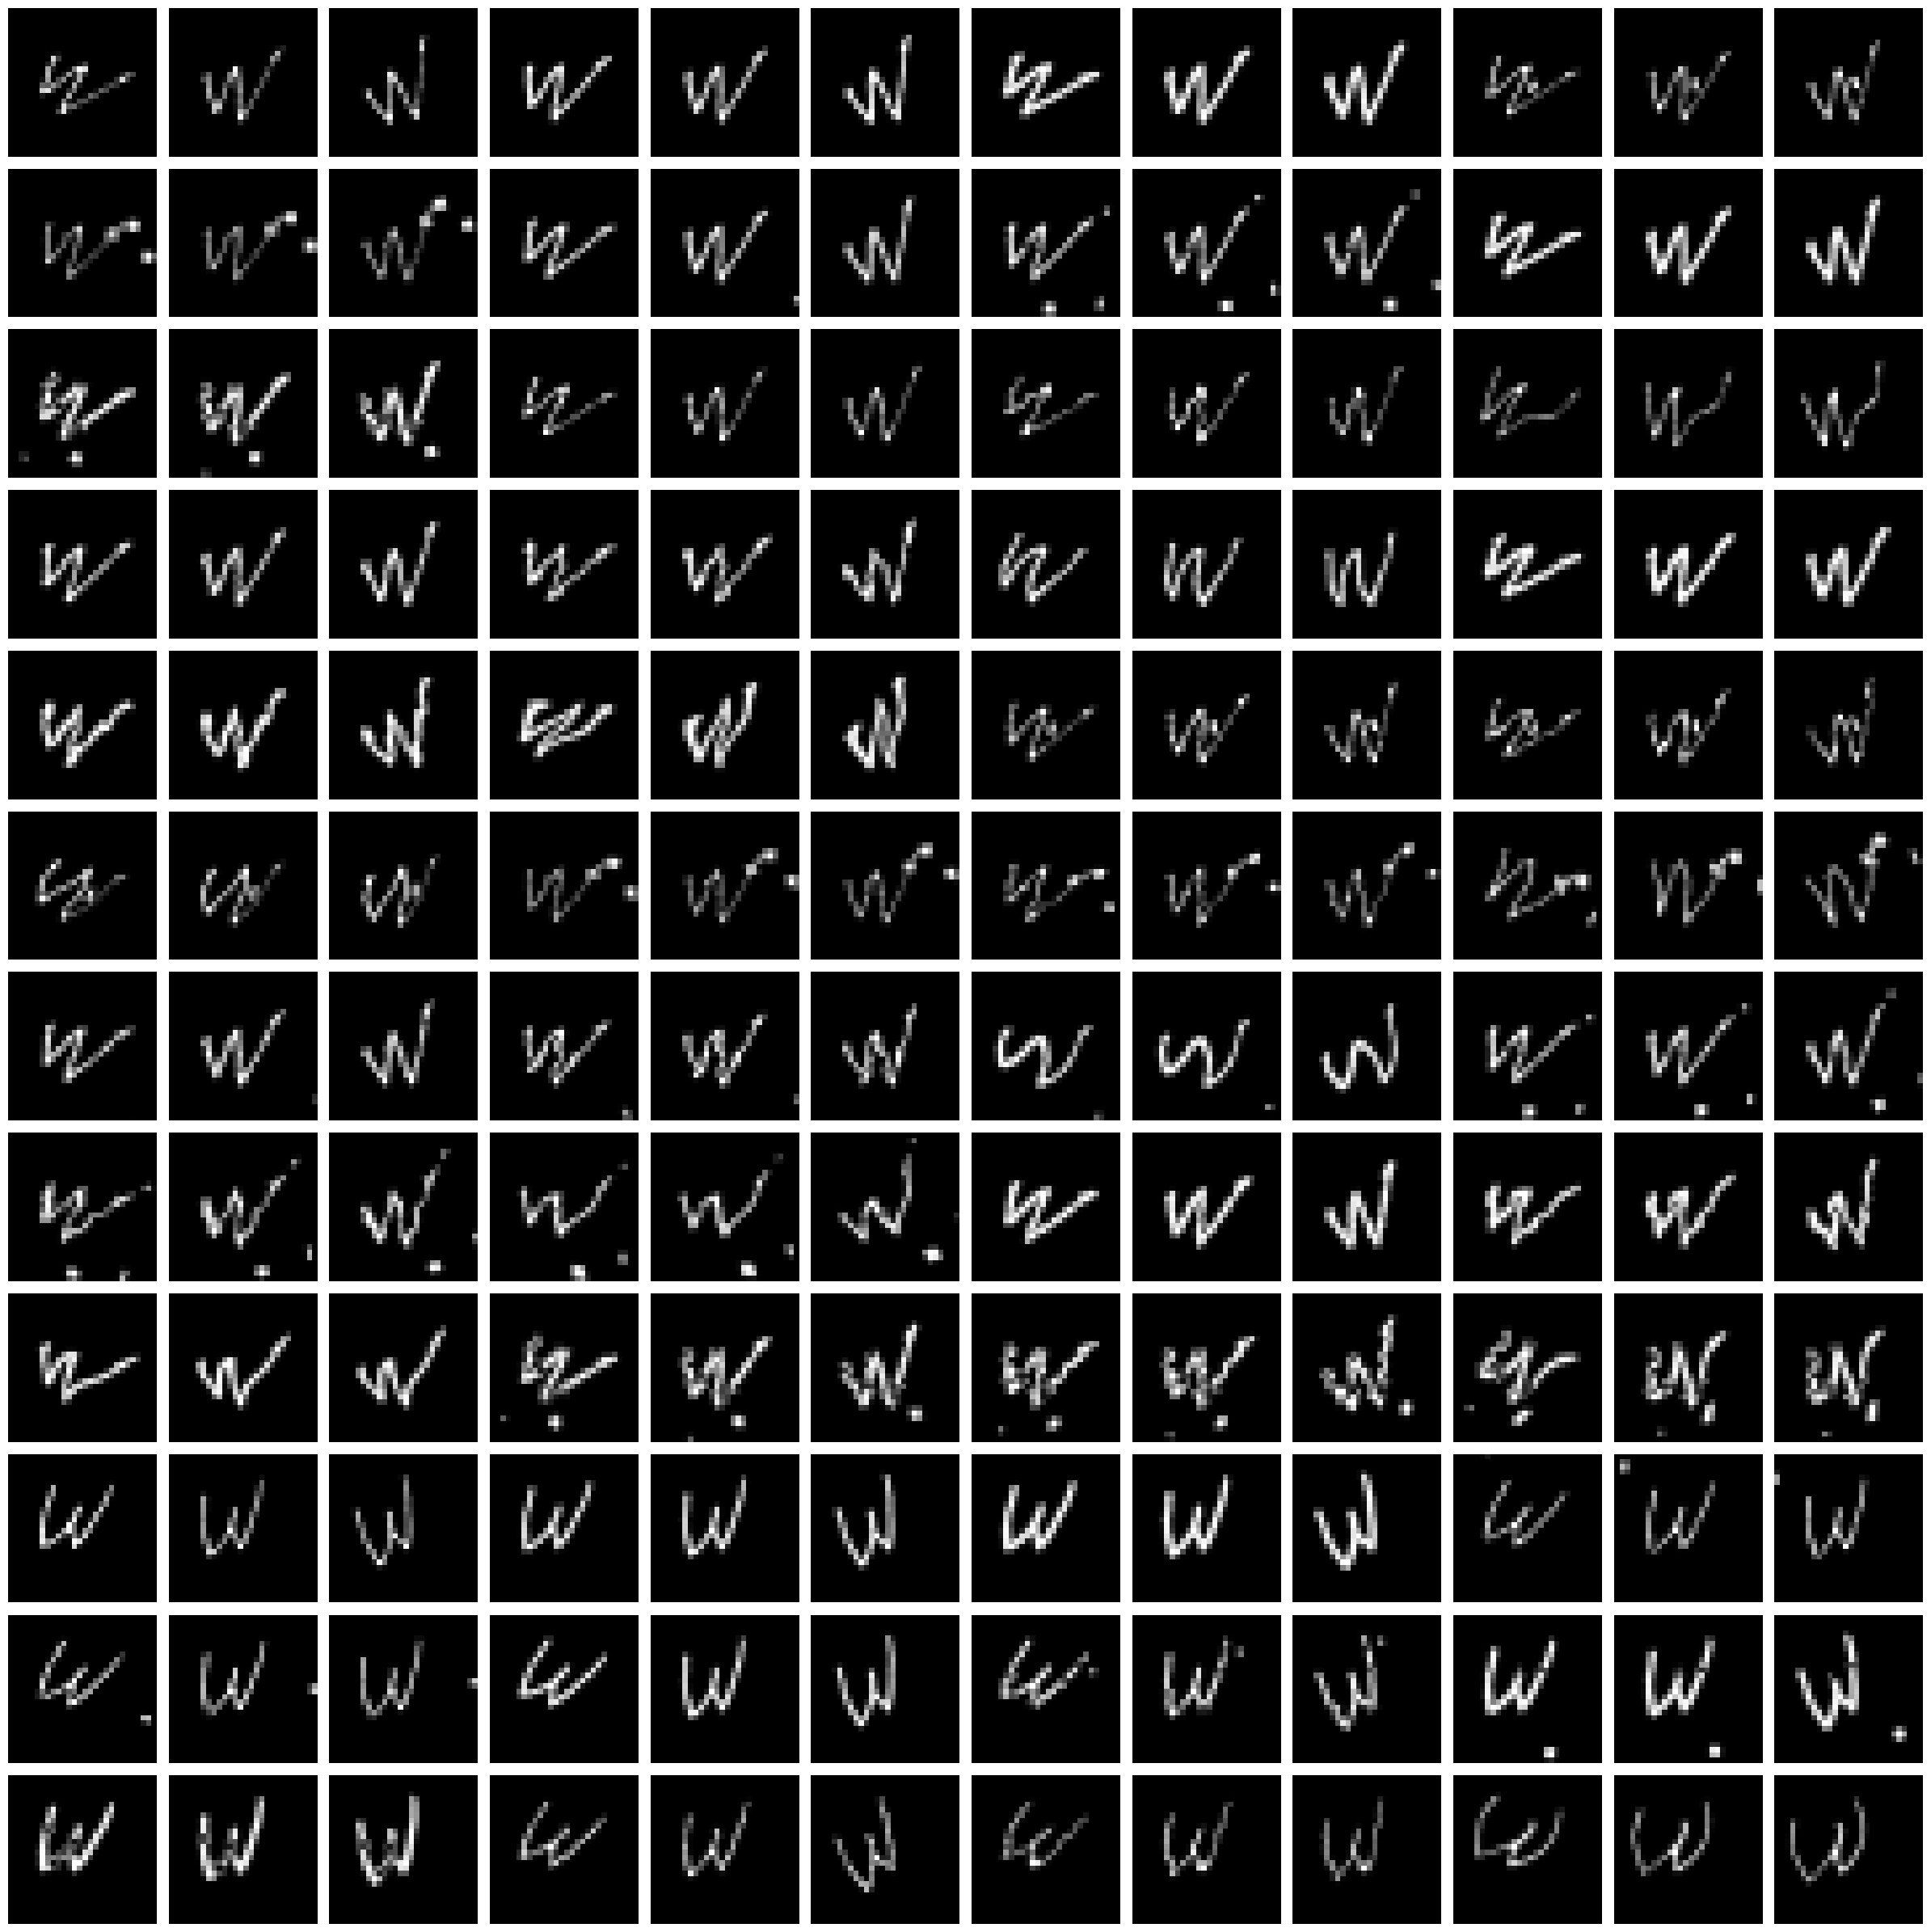

In [29]:
plt.figure(figsize=(24, 24))

for i in range(12):
    
    for j in range(12):
        plt.subplot(12, 12, i*12+j+1)
        plt.imshow(X_train[i*12+j+6*144*17, :, :], cmap='gray')
        plt.axis('off')
plt.tight_layout()
plt.show()

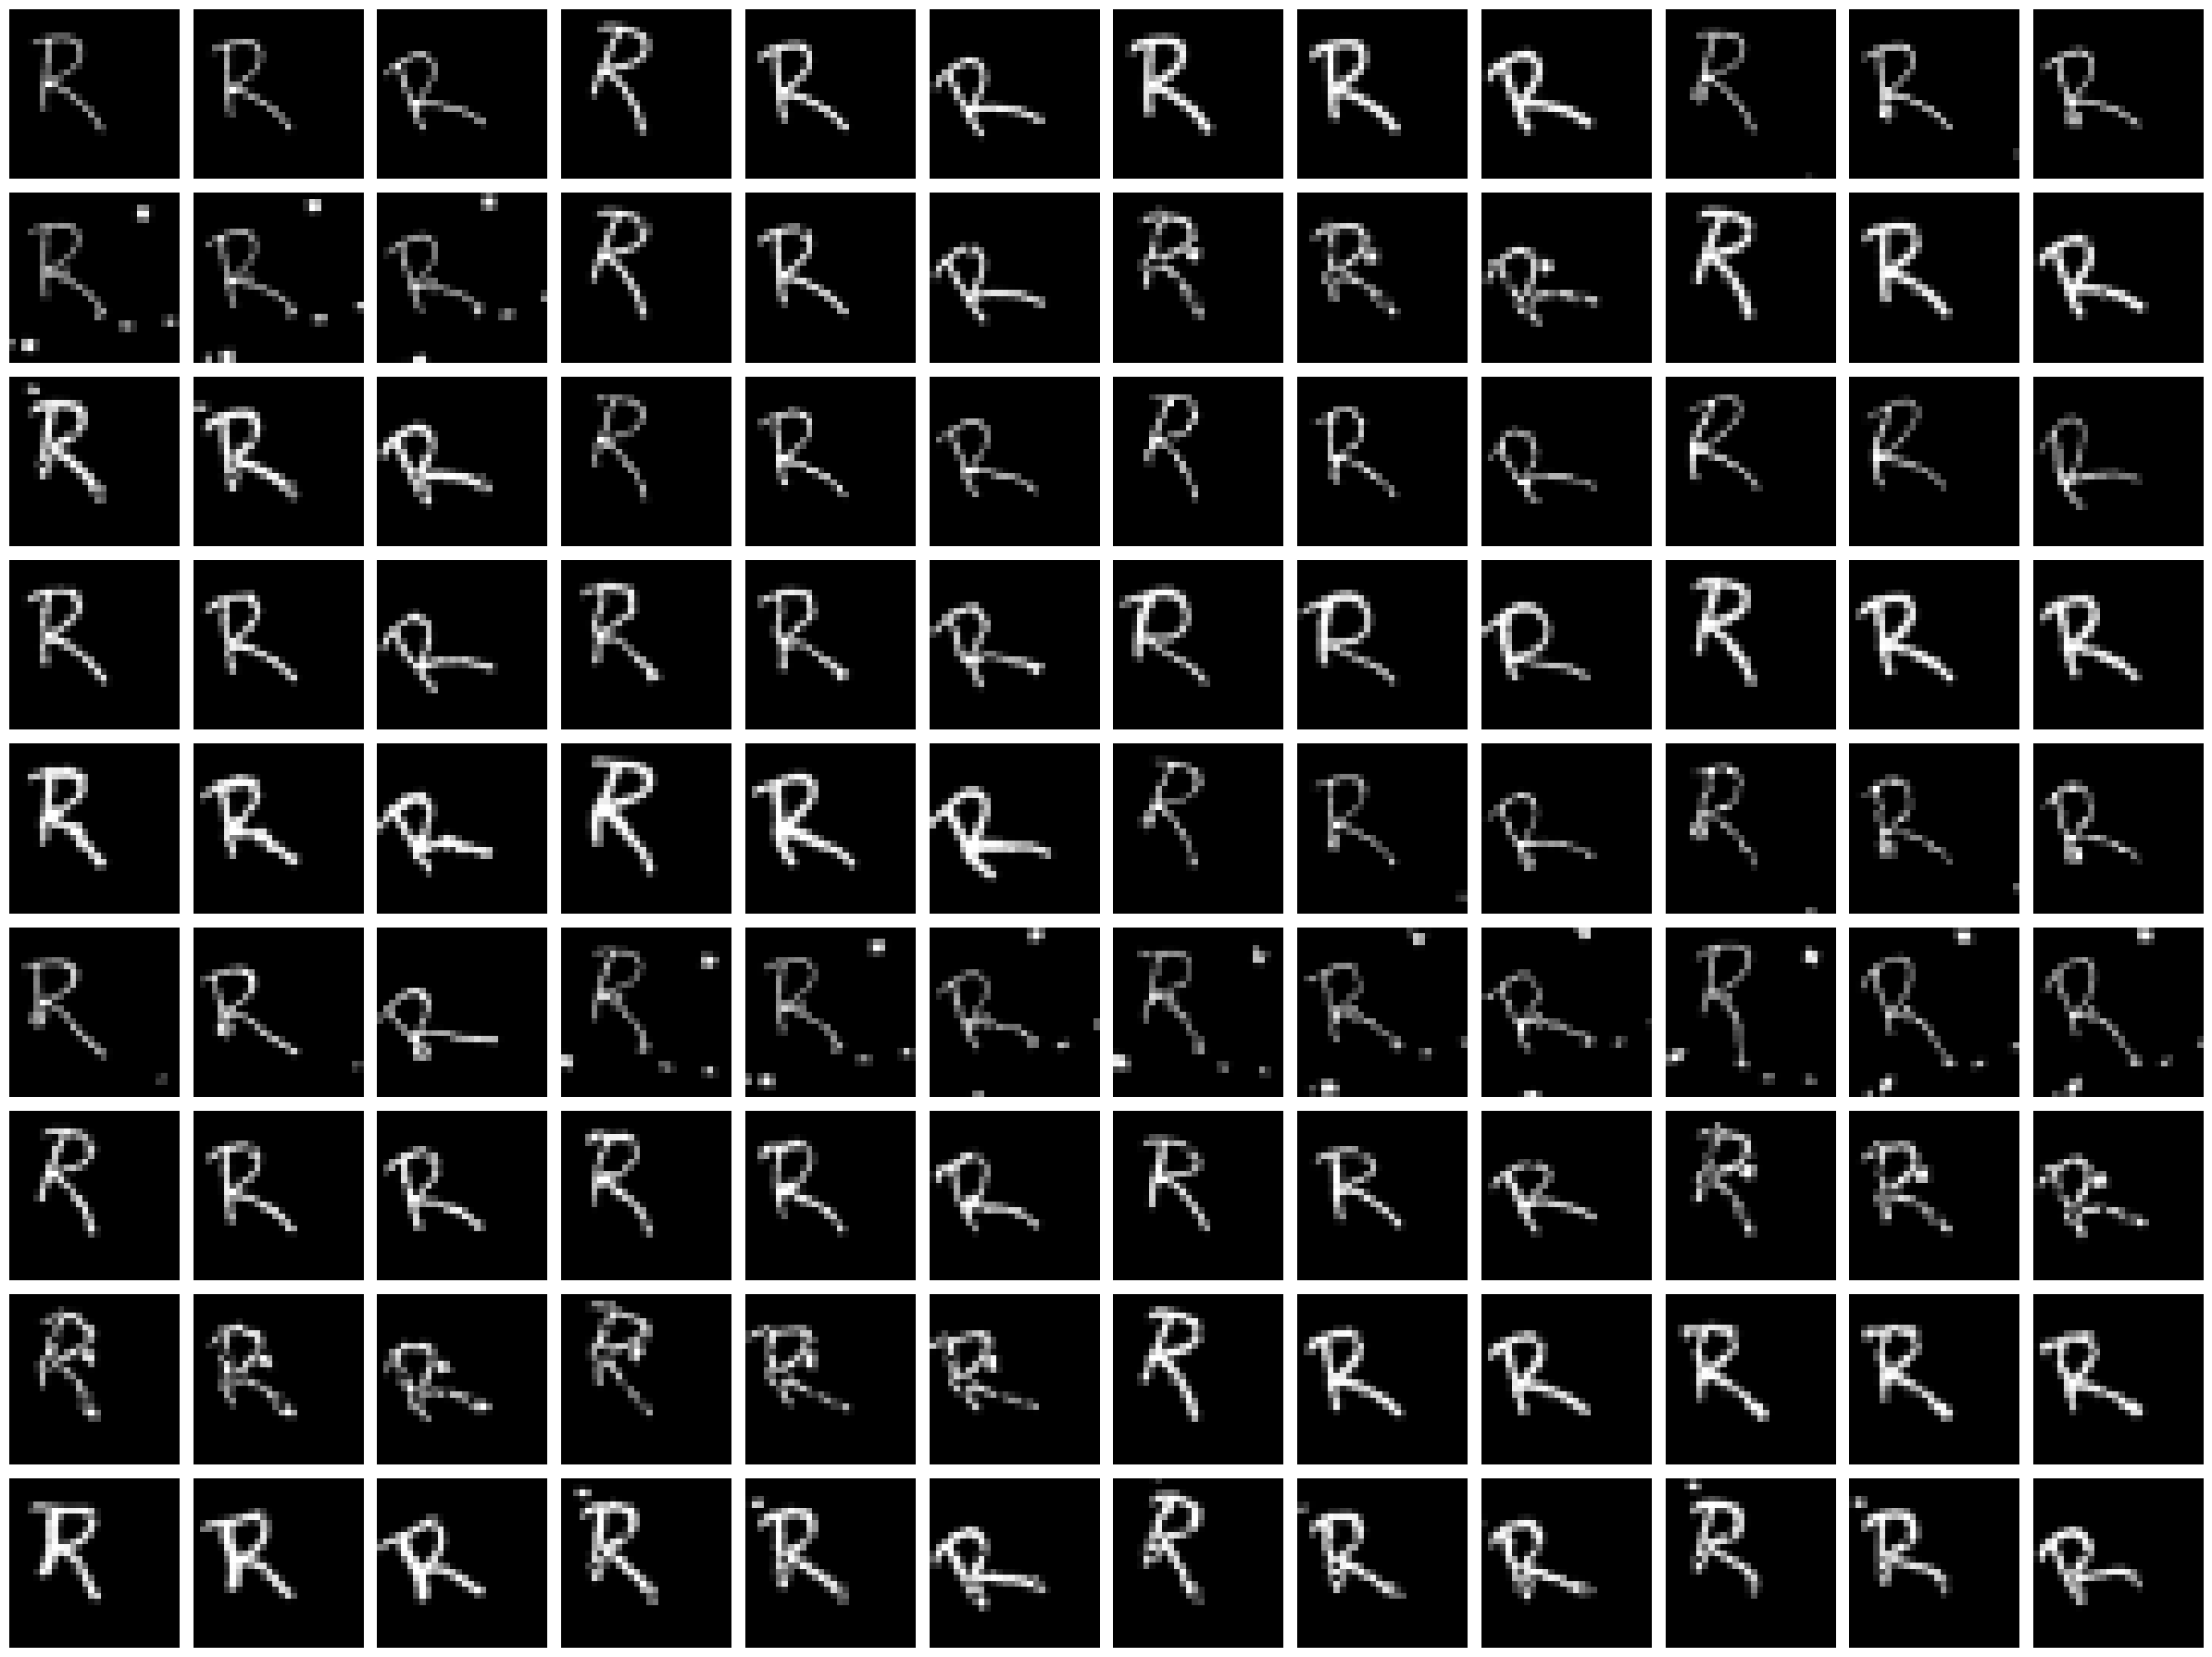

In [31]:
plt.figure(figsize=(24, 18))

for i in range(9):
    
    for j in range(12):
        plt.subplot(9, 12, i*12+j+1)
        plt.imshow(X_train[i*12+j+6*108*17, :, :], cmap='gray')
        plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
for i in range(26):
    for j in range(6):
        

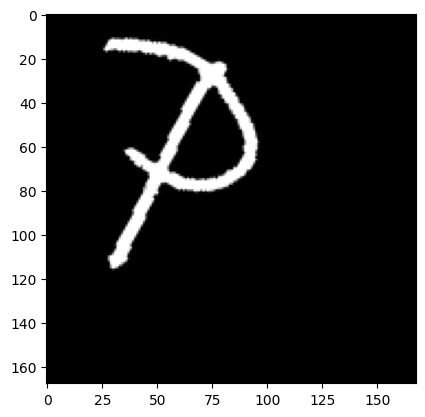

In [ ]:

a = letters[15, 0, :, :]
angle = -30
scale = 1.0
rotation_matrix = cv2.getRotationMatrix2D((168//2, 168//2), angle, scale)
rotated = cv2.warpAffine(a, rotation_matrix, (168, 168))
plt.imshow(rotated, cmap='gray')
plt.show()

TypeError: Invalid shape (168,) for image data

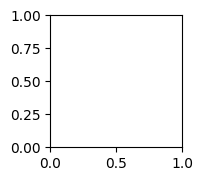

In [ ]:
a = thickness(letters[0, 0, :, :])
plt.figure(figsize=(6, 12))

for i in range(6):
    
    for j in range(3):
        plt.subplot(6, 3, i*3+j+1)
        plt.imshow(a[j, i], cmap='gray')
        plt.axis('off')
plt.tight_layout()
plt.show()

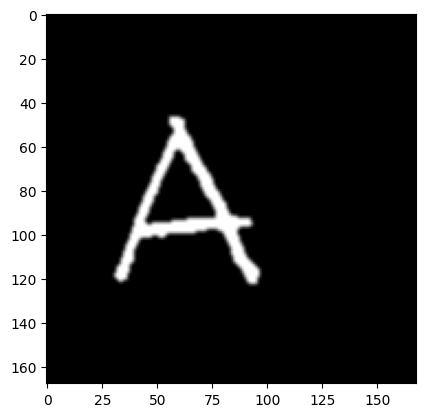

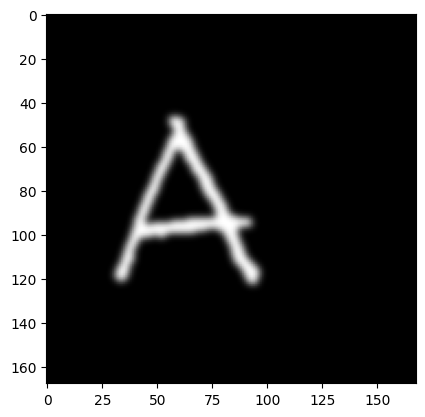

In [ ]:
a = letters[0, 0, :, :]
#a = noise(a, 0.005)
a = cv2.GaussianBlur(a, (3, 3), 0)
plt.imshow(a, cmap='gray')

plt.show()
a = letters[0, 0, :, :]
a = cv2.GaussianBlur(a, (9, 9), 0)
plt.imshow(a, cmap='gray')
plt.show()

In [ ]:
np.savez('C:/Users/milan/Downloads/imlproject/letters.npz', letters=letters)